# Analisis Exploratorio de datos

## Librerias

In [1]:
import os
import cv2
import random
import math

import numpy as np
import pandas as pd

import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib.patches as patches

plt.rcParams.update({'font.size': 18})
plt.style.use('fivethirtyeight')

import seaborn as sns
import matplotlib
from dask import bag, diagnostics 
from mpl_toolkits.mplot3d import Axes3D
from termcolor import colored
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn import functional as F
import torch.backends.cudnn as cudnn
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, Dataset, sampler

from sklearn.model_selection import KFold
import warnings
warnings.simplefilter('ignore')

# Activate pandas progress apply bar
tqdm.pandas()

In [2]:
class config:
    DIRECTORY_PATH = r"C:\Users\Hp\Documents\Deep_learning\Imagenes\sartorius-cell-instance-segmentation"
    TRAIN_CSV = DIRECTORY_PATH + r"\train.csv"
    TRAIN_PATH = DIRECTORY_PATH + r"\train"
    TEST_PATH = DIRECTORY_PATH + r"\test"
    TRAIN_SEMI_SUPERVISED_PATH = DIRECTORY_PATH + r"\train_semi_supervised"
    SEED = 0

    # (336, 336)
    IMAGE_RESIZE = (224, 224)

## Funciones

In [3]:
def getImagePaths(path):
    """
    Function to Combine Directory Path with individual Image Paths
    
    parameters: path(string) - Path of directory
    returns: image_names(string) - Full Image Path
    """
    image_names = []
    for dirname, _, filenames in os.walk(path):
        for filename in tqdm(filenames):
            fullpath = os.path.join(dirname, filename)
            image_names.append(fullpath)
    return image_names

## Cargado de datos e imagenes 

In [4]:
df_train = pd.read_csv(config.TRAIN_CSV)

In [5]:
train_images_path = getImagePaths(config.TRAIN_PATH)
test_images_path = getImagePaths(config.TEST_PATH)

100%|██████████| 3/3 [00:00<00:00, 2357.23it/s]


In [6]:
df_train.head()

,id,annotation,width,height,cell_type,plate_time,sample_date,sample_id,elapsed_timedelta
0,0030fd0e6378,118145 6 118849 7 119553 8 120257 8 120961 9 1...,704,520,shsy5y,11h30m00s,2019-06-16,shsy5y[diff]_E10-4_Vessel-714_Ph_3,0 days 11:30:00
1,0030fd0e6378,189036 1 189739 3 190441 6 191144 7 191848 8 1...,704,520,shsy5y,11h30m00s,2019-06-16,shsy5y[diff]_E10-4_Vessel-714_Ph_3,0 days 11:30:00
2,0030fd0e6378,173567 3 174270 5 174974 5 175678 6 176382 7 1...,704,520,shsy5y,11h30m00s,2019-06-16,shsy5y[diff]_E10-4_Vessel-714_Ph_3,0 days 11:30:00
3,0030fd0e6378,196723 4 197427 6 198130 7 198834 8 199538 8 2...,704,520,shsy5y,11h30m00s,2019-06-16,shsy5y[diff]_E10-4_Vessel-714_Ph_3,0 days 11:30:00
4,0030fd0e6378,167818 3 168522 5 169225 7 169928 8 170632 9 1...,704,520,shsy5y,11h30m00s,2019-06-16,shsy5y[diff]_E10-4_Vessel-714_Ph_3,0 days 11:30:00


In [7]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73585 entries, 0 to 73584
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 73585 non-null  object
 1   annotation         73585 non-null  object
 2   width              73585 non-null  int64 
 3   height             73585 non-null  int64 
 4   cell_type          73585 non-null  object
 5   plate_time         73585 non-null  object
 6   sample_date        73585 non-null  object
 7   sample_id          73585 non-null  object
 8   elapsed_timedelta  73585 non-null  object
dtypes: int64(2), object(7)
memory usage: 5.1+ MB


In [8]:
print(f"Training Dataset Shape: {df_train.shape}")

Training Dataset Shape: (73585, 9)


In [9]:
for col in df_train.columns:
    print(col + ":" + (str(len(df_train[col].unique()))))

id:606
annotation:73470
width:1
height:1
cell_type:3
plate_time:8
sample_date:18
sample_id:403
elapsed_timedelta:8


In [10]:
print(f"Number of train images: {(len(train_images_path))}")
print(f"Number of test images:  {(len(test_images_path))}")

Number of train images: 606
Number of test images:  3


In [11]:
def plot_distribution(x):

    fig = px.histogram(
    df_train, 
    x = x,
    width = 800,
    height = 500,
    )
    
    fig.show()

In [12]:
plot_distribution('cell_type')

In [13]:
plot_distribution('plate_time')

In [14]:
plot_distribution('elapsed_timedelta')

In [15]:
def rle_decode(mask_rle, shape):
    '''
    mask_rle: string RLE (start length)
    shape: (height, width)
    Returns: máscara binaria (h, w)
    '''
    s = list(map(int, mask_rle.split()))
    
    starts = np.array(s[0::2]) - 1
    lengths = np.array(s[1::2])
    ends = starts + lengths

    img = np.zeros(shape[0] * shape[1], dtype=np.uint8)

    for start, end in zip(starts, ends):
        img[start:end] = 1

    return img.reshape(shape)

In [16]:
def rle_area(mask_rle):
    s = mask_rle.split()
    lengths = list(map(int, s[1::2]))
    return sum(lengths)

## Construccion de dataframe

In [17]:
def compute_mask_area(rle: str) -> int:
    """Área de una máscara usando RLE (sin decodificar)."""
    if pd.isna(rle):
        return 0
    s = list(map(int, rle.split()))
    return sum(s[1::2])  # suma de longitudes


def build_dataframe(df_train, images_path):
    records = []

    grouped = df_train.groupby('id')

    for img_id, grp in tqdm(grouped, desc='Procesando imágenes'):
        
        # metadata básica
        h = grp['height'].iloc[0]
        w = grp['width'].iloc[0]
        cell_type = grp['cell_type'].iloc[0]

        # ruta imagen
        image_path = os.path.join(images_path, img_id + '.png')  # cambia a .tif si aplica

        # máscaras válidas (evita NaN)
        annotations = grp['annotation'].dropna()

        # número de máscaras
        n_masks = len(annotations)

        # áreas individuales
        areas = [compute_mask_area(rle) for rle in annotations]

        # manejar edge case: imágenes sin máscaras
        if len(areas) == 0:
            area_total = 0
            area_mean  = 0
            area_max   = 0
            area_min   = 0
        else:
            area_total = sum(areas)
            area_mean  = np.mean(areas)
            area_max   = max(areas)
            area_min   = min(areas)

        records.append({
            'id_imagen'   : img_id,
            'ruta_imagen' : image_path,
            'cell_type'   : cell_type,
            'width'       : w,
            'height'      : h,
            'n_mascaras'  : n_masks,
            'area_total'  : area_total,
            'area_media'  : area_mean,
            'area_max'    : area_max,
            'area_min'    : area_min,
            'areas'       : areas,
        })

    return pd.DataFrame(records)

In [18]:
df_img = build_dataframe(df_train, config.TRAIN_PATH)

print(df_img.shape)
df_img.head()

Procesando imágenes: 100%|██████████| 606/606 [00:00<00:00, 1163.76it/s]

(606, 11)


,id_imagen,ruta_imagen,cell_type,width,height,n_mascaras,area_total,area_media,area_max,area_min,areas
0,0030fd0e6378,C:\Users\Hp\Documents\Deep_learning\Imagenes\s...,shsy5y,704,520,395,113307,286.853165,757,46,"[498, 228, 301, 521, 327, 178, 345, 154, 283, ..."
1,0140b3c8f445,C:\Users\Hp\Documents\Deep_learning\Imagenes\s...,astro,704,520,108,86735,803.101852,7126,138,"[1282, 673, 577, 138, 450, 467, 1067, 808, 524..."
2,01ae5a43a2ab,C:\Users\Hp\Documents\Deep_learning\Imagenes\s...,cort,704,520,36,11382,316.166667,522,149,"[262, 458, 196, 204, 522, 236, 345, 161, 149, ..."
3,026b3c2c4b32,C:\Users\Hp\Documents\Deep_learning\Imagenes\s...,cort,704,520,42,7660,182.380952,355,84,"[172, 182, 151, 197, 156, 187, 175, 126, 245, ..."
4,029e5b3b89c7,C:\Users\Hp\Documents\Deep_learning\Imagenes\s...,cort,704,520,34,5753,169.205882,277,107,"[212, 125, 116, 223, 211, 221, 107, 188, 183, ..."


In [19]:
df_img.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 606 entries, 0 to 605
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id_imagen    606 non-null    object 
 1   ruta_imagen  606 non-null    object 
 2   cell_type    606 non-null    object 
 3   width        606 non-null    int64  
 4   height       606 non-null    int64  
 5   n_mascaras   606 non-null    int64  
 6   area_total   606 non-null    int64  
 7   area_media   606 non-null    float64
 8   area_max     606 non-null    int64  
 9   area_min     606 non-null    int64  
 10  areas        606 non-null    object 
dtypes: float64(1), int64(6), object(4)
memory usage: 52.2+ KB


## Analisis de graficos de altura y anchura

In [20]:
sns.set_style("whitegrid")

# Paletas
palette_main = sns.color_palette("Set2")
palette_alt  = sns.color_palette("husl", 8)

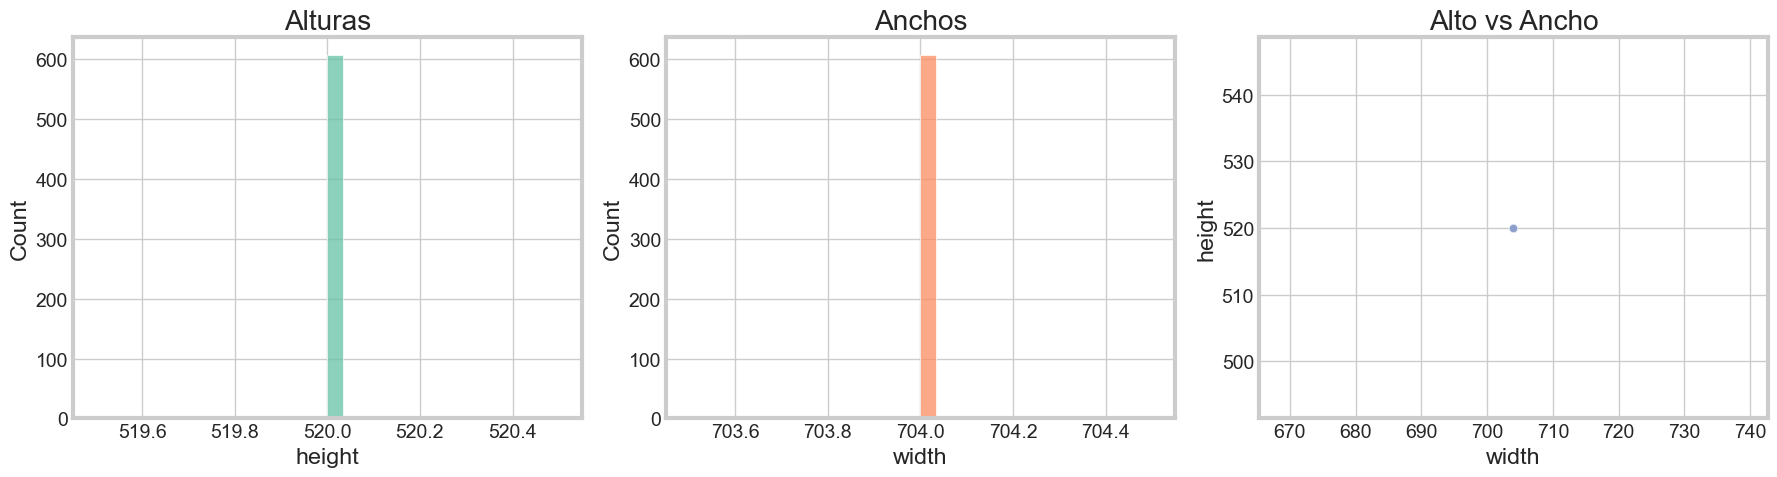

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Alturas
sns.histplot(df_img['height'], bins=30, color=palette_main[0], ax=axes[0])
axes[0].set_title('Alturas')

# Anchos
sns.histplot(df_img['width'], bins=30, color=palette_main[1], ax=axes[1])
axes[1].set_title('Anchos')

# Scatter
sns.scatterplot(
    x=df_img['width'],
    y=df_img['height'],
    color=palette_main[2],
    alpha=0.6,
    ax=axes[2]
)
axes[2].set_title('Alto vs Ancho')

plt.tight_layout()
plt.show()

podemos observar que las imagenes tienen 520 de alto y 704 de ancho y todas tienen las mismas dimensiones


## Analisis de celulas 

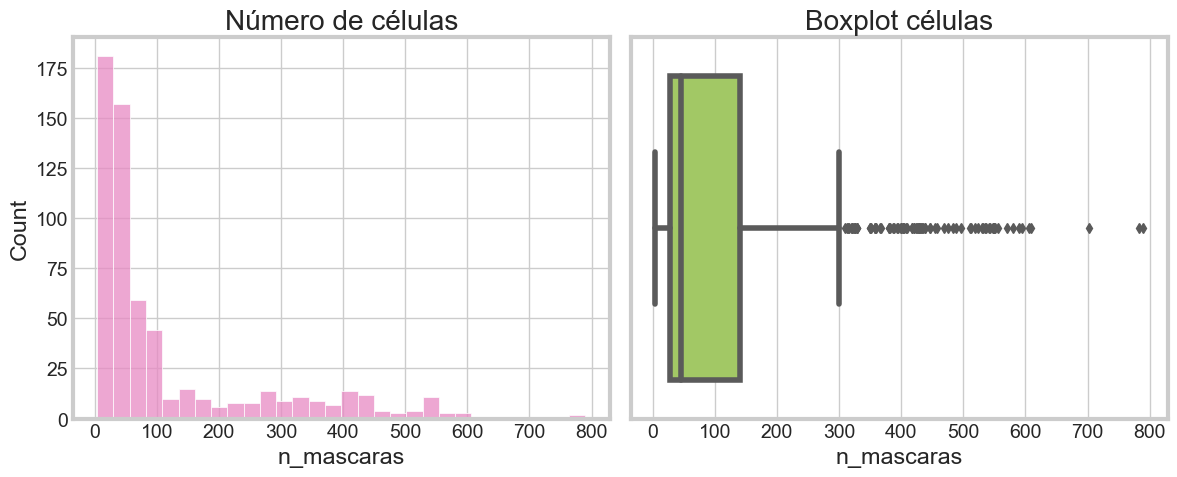

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histograma
sns.histplot(df_img['n_mascaras'], bins=30, color=palette_main[3], ax=axes[0])
axes[0].set_title('Número de células')

# Boxplot
sns.boxplot(x=df_img['n_mascaras'], color=palette_main[4], ax=axes[1])
axes[1].set_title('Boxplot células')

plt.tight_layout()
plt.show()

**Análisis exploratorio: distribución del número de células (máscaras)**

Se presenta la distribución del número de máscaras por imagen en el dataset de Sartorius, a través de un histograma y un diagrama de caja (boxplot), con el objetivo de caracterizar la complejidad estructural de las imágenes.

**Distribución de frecuencias**

El histograma evidencia que la variable `n_mascaras` presenta una **distribución fuertemente sesgada a la derecha**. La mayoría de las imágenes contienen un número relativamente bajo de células (principalmente en el rango de 0 a 100), mientras que existe una **cola larga** que se extiende hasta valores cercanos a 800 máscaras.

Este comportamiento indica la presencia de un **desbalance en la densidad celular**, donde predominan imágenes simples (pocas células) frente a un menor número de imágenes altamente densas.

**Análisis de dispersión**

El boxplot confirma los hallazgos anteriores:

* La **mediana** se ubica en valores bajos, consistente con la concentración de datos en imágenes poco densas.
* El **rango intercuartílico (IQR)** es relativamente estrecho y se concentra en valores bajos.
* Se observan **numerosos valores atípicos (outliers)** hacia la derecha, correspondientes a imágenes con alta densidad celular.

Estos resultados evidencian que la distribución no es normal y está dominada por valores extremos en el extremo superior.

**Implicaciones para el modelado**

La estructura observada tiene varias implicaciones relevantes:

* Existe un **desbalance en la complejidad de las muestras**, lo que puede sesgar el entrenamiento hacia casos más simples.
* Los modelos pueden presentar dificultades para generalizar en imágenes con alta densidad celular.
* Métricas globales de desempeño podrían estar dominadas por ejemplos de baja complejidad.

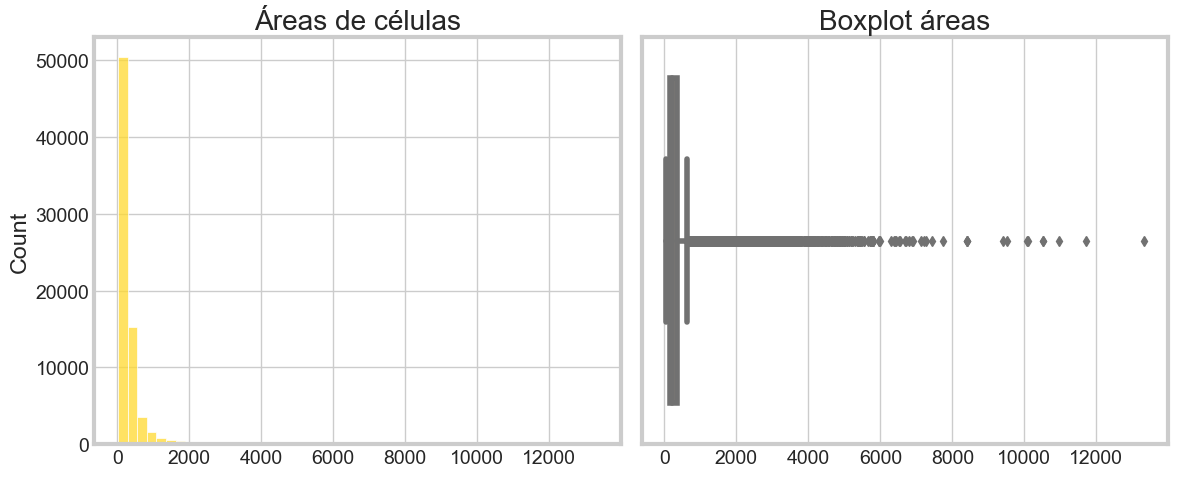

In [23]:
all_areas = [area for sublist in df_img['areas'] for area in sublist]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histograma
sns.histplot(all_areas, bins=50, color=palette_main[5], ax=axes[0])
axes[0].set_title('Áreas de células')

# Boxplot
sns.boxplot(x=all_areas, color=palette_main[6], ax=axes[1])
axes[1].set_title('Boxplot áreas')

plt.tight_layout()
plt.show()

**Análisis exploratorio: distribución de áreas de células**

Se analiza la distribución de las áreas de las células segmentadas en el dataset de Sartorius mediante un histograma y un diagrama de caja (boxplot), con el fin de comprender la variabilidad en el tamaño de los objetos de interés.

**Distribución de frecuencias**

El histograma muestra que las áreas celulares presentan una **distribución altamente sesgada a la derecha**. La gran mayoría de las células tienen áreas pequeñas, concentrándose en los primeros rangos, mientras que existe una **cola larga** que alcanza valores extremadamente altos (por encima de 10,000).

Este patrón indica que predominan células pequeñas, coexistiendo con un número reducido de células de gran tamaño.

**Análisis de dispersión**

El boxplot refuerza estos hallazgos:

* La **mediana** se encuentra en valores bajos, reflejando la predominancia de células pequeñas.
* El **rango intercuartílico (IQR)** es estrecho y concentrado en áreas pequeñas.
* Se identifican **numerosos valores atípicos (outliers)** hacia valores altos, correspondientes a células significativamente más grandes que la mayoría.

Esto evidencia una distribución no normal, con presencia marcada de valores extremos.

**Implicaciones para el modelado**

La heterogeneidad en el tamaño de las células tiene implicaciones importantes:

* Los modelos pueden **favorecer la detección de células pequeñas**, debido a su alta frecuencia en el dataset.
* Las células grandes, al ser menos frecuentes, pueden ser más difíciles de segmentar correctamente.
* Existe riesgo de sesgo en métricas globales, donde el desempeño en objetos pequeños domine la evaluación.


## Analisis de pixeles y canales de color

In [24]:
pixel_values = []

# sample para no cargar todo el dataset (muy importante)
sample_df = df_img.sample(min(50, len(df_img)), random_state=0)

for path in sample_df['ruta_imagen']:
    img = cv2.imread(path)

    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # convertir a lista de píxeles (N x 3)
    pixel_values.append(img.reshape(-1, 3))

# concatenar todo
pixel_values = np.vstack(pixel_values)

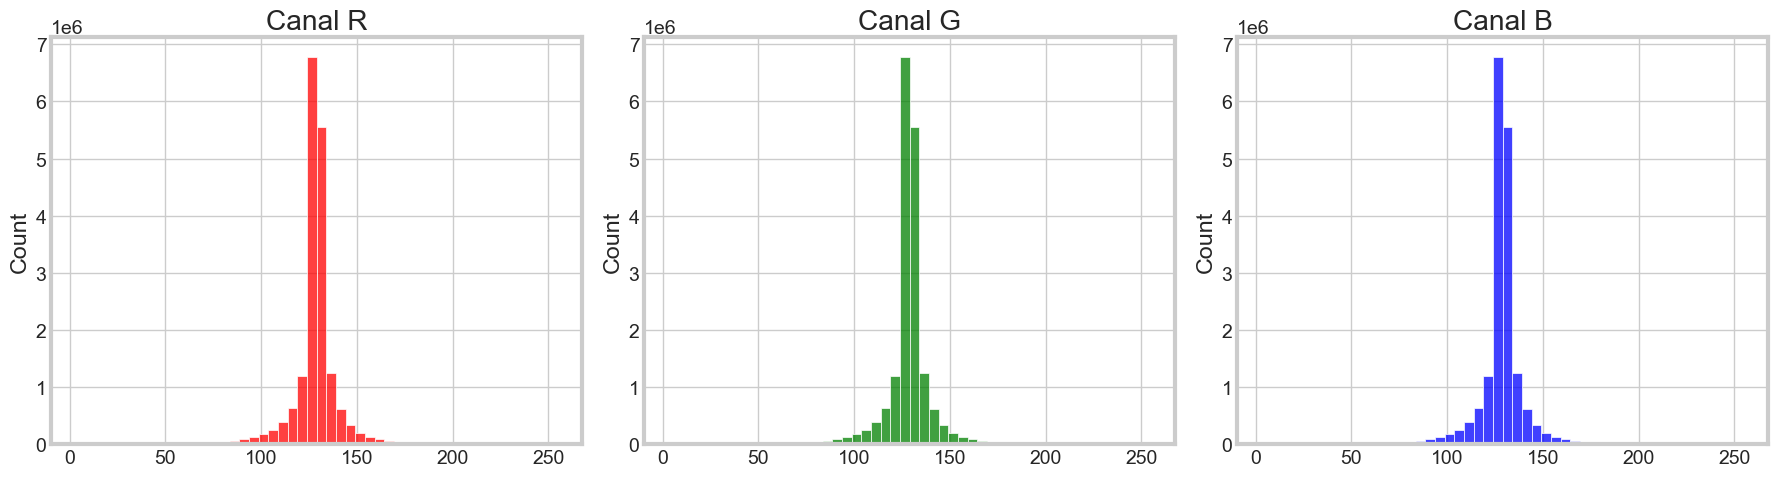

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

channels = ['R', 'G', 'B']
colors   = ['red', 'green', 'blue']

for i in range(3):
    sns.histplot(pixel_values[:, i], bins=50, color=colors[i], ax=axes[i])
    axes[i].set_title(f'Canal {channels[i]}')

plt.tight_layout()
plt.show()

**Análisis exploratorio: distribución de intensidades RGB**

Se analiza la distribución de intensidades de los canales de color RGB (Red, Green y Blue) en las imágenes del dataset de Sartorius, con el objetivo de identificar patrones de iluminación, contraste y composición cromática presentes en los datos.

**Distribución de intensidades por canal**

Los histogramas correspondientes a los canales R, G y B presentan comportamientos muy similares:

* Las distribuciones se encuentran **altamente concentradas en un rango estrecho de intensidades**, aproximadamente entre 110 y 145.
* Se observa una forma aproximadamente simétrica y unimodal alrededor de un valor central cercano a 128.
* No existen concentraciones relevantes en valores extremos cercanos a 0 o 255.

Esto sugiere que las imágenes poseen una iluminación relativamente homogénea y una exposición bien controlada.

**Comparación entre canales**

Los tres canales presentan distribuciones prácticamente equivalentes:

* No se evidencia predominancia significativa de un color específico.
* Las diferencias entre canales son mínimas, lo que indica una composición cromática balanceada.
* La similitud entre distribuciones sugiere baja variabilidad en condiciones de adquisición o preprocesamiento de las imágenes.

**Implicaciones para el modelado**

Los resultados obtenidos tienen varias implicaciones importantes:

* La homogeneidad de intensidades puede facilitar el proceso de entrenamiento, reduciendo variaciones asociadas a iluminación.
* La ausencia de extremos pronunciados disminuye la probabilidad de saturación o pérdida de información visual.
* La similitud entre canales sugiere que gran parte de la información discriminativa podría encontrarse en las estructuras espaciales y texturas, más que en diferencias cromáticas.


In [26]:
import numpy as np

def overlay_masks(image, masks, alpha=0.5):
    overlay = image.copy()
    colors = sns.color_palette("husl", len(masks))

    for mask, color in zip(masks, colors):
        color = np.array(color) * 255  

        overlay[mask == 1] = (
            overlay[mask == 1] * (1 - alpha) +
            color * alpha
        )

    return overlay.astype(np.uint8)

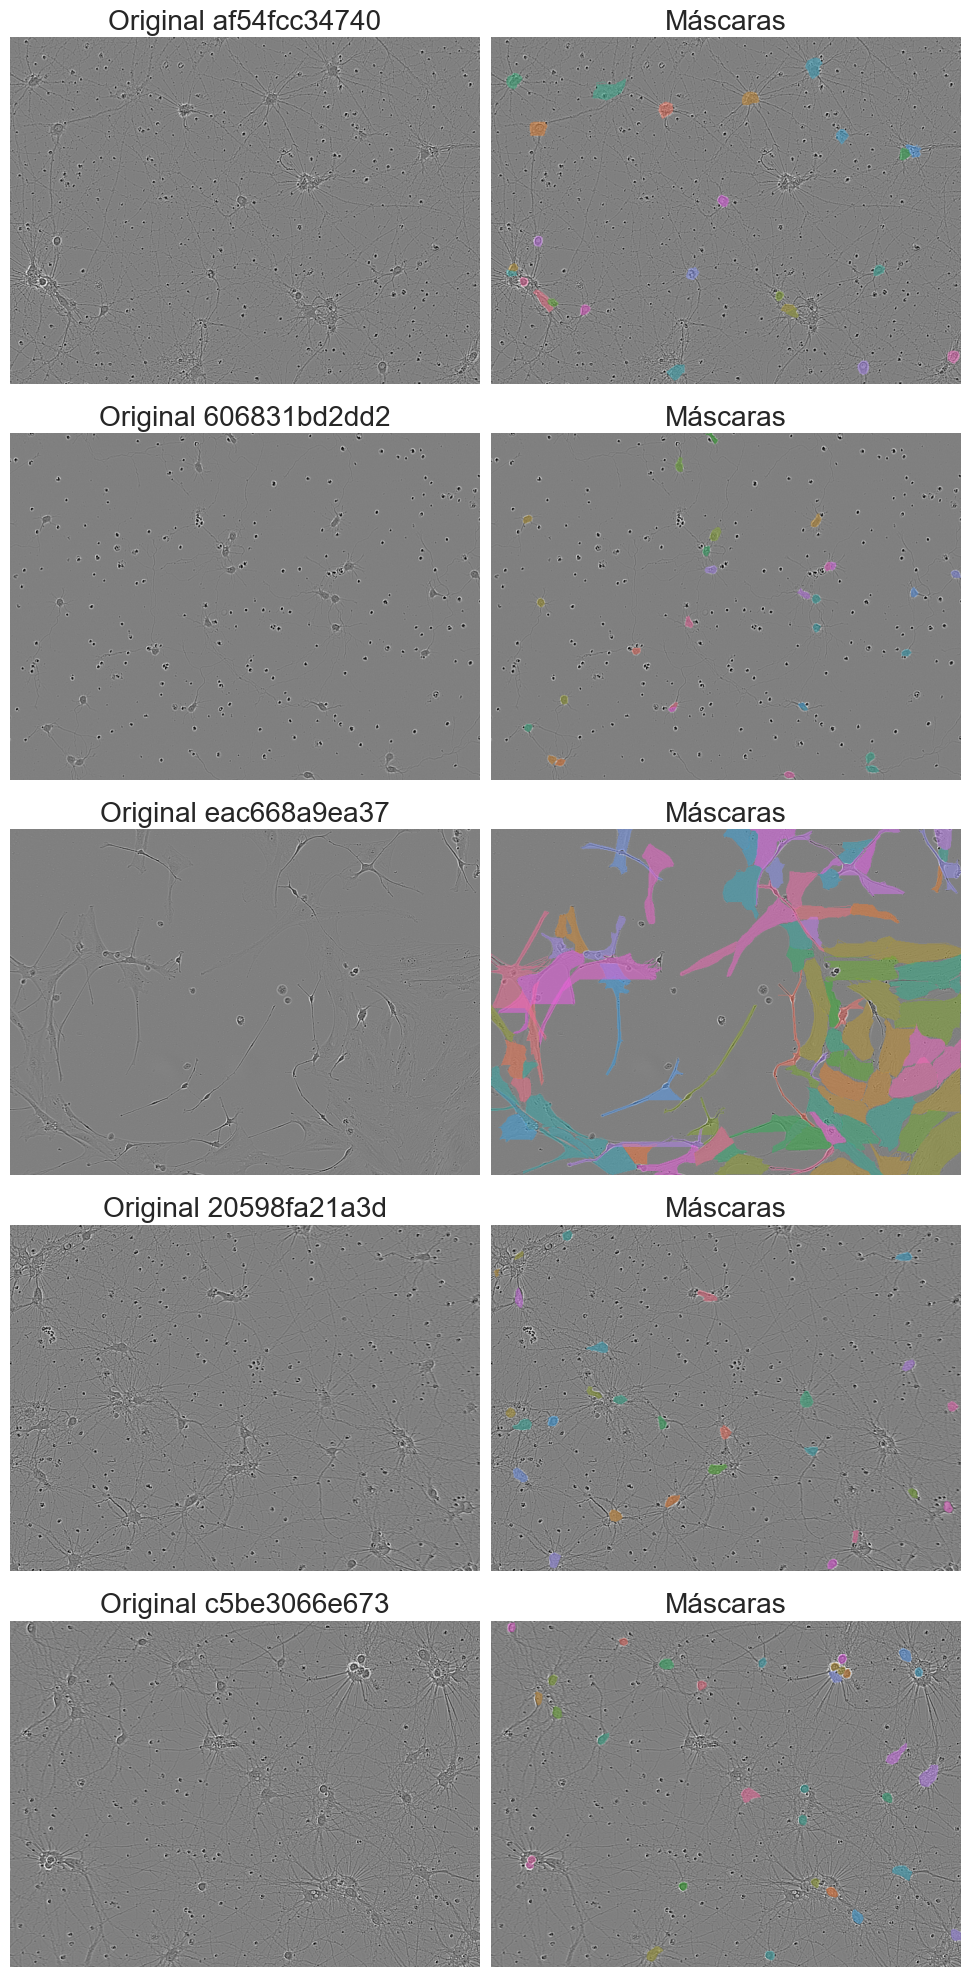

In [27]:
fig, axes = plt.subplots(5, 2, figsize=(10, 20))

sample_ids = random.sample(list(df_img['id_imagen']), 5)

for i, img_id in enumerate(sample_ids):
    
    row = df_img[df_img['id_imagen'] == img_id].iloc[0]
    path = row['ruta_imagen']
    
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w = row['height'], row['width']
    
    rles = df_train[df_train['id'] == img_id]['annotation'].dropna().tolist()
    masks = [rle_decode(rle, (h, w)) for rle in rles]

    overlay = overlay_masks(img, masks)

    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f'Original {img_id}')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(overlay)
    axes[i, 1].set_title('Máscaras')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

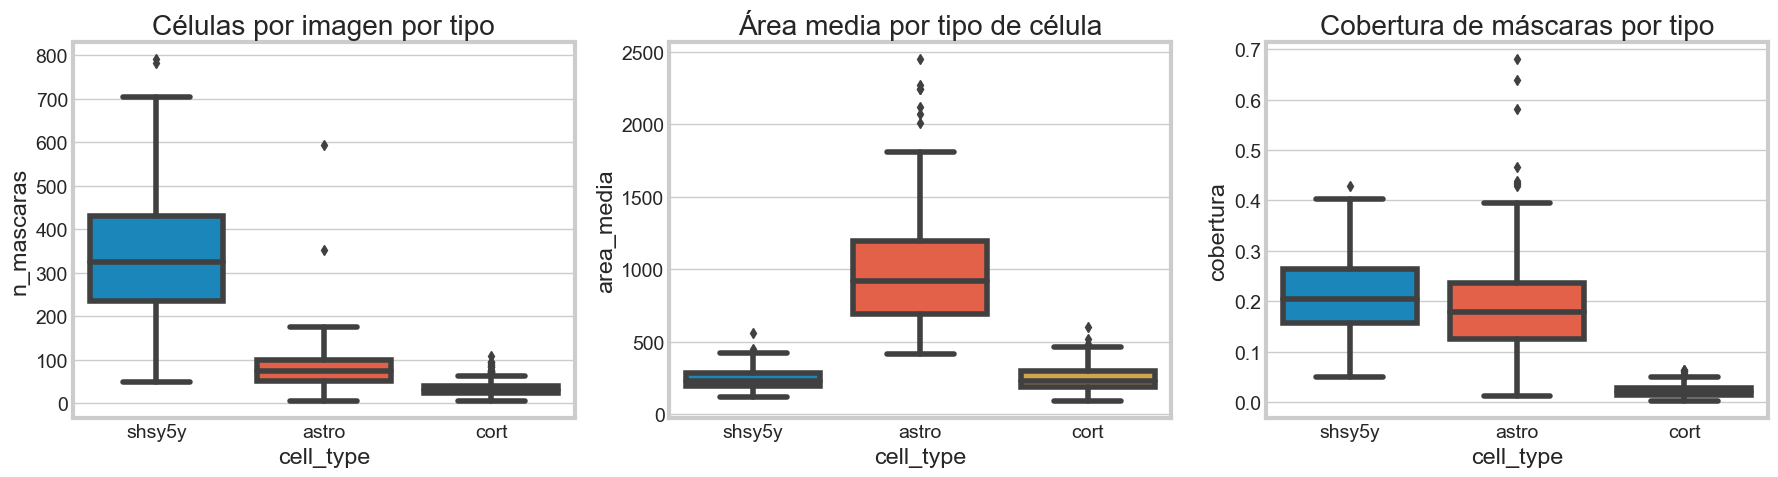

In [28]:
# 1. Métricas por cell_type
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df_img, x='cell_type', y='n_mascaras', ax=axes[0])
axes[0].set_title('Células por imagen por tipo')

sns.boxplot(data=df_img, x='cell_type', y='area_media', ax=axes[1])
axes[1].set_title('Área media por tipo de célula')

# Cobertura = qué % de la imagen está anotado
df_img['cobertura'] = df_img['area_total'] / (df_img['height'] * df_img['width'])
sns.boxplot(data=df_img, x='cell_type', y='cobertura', ax=axes[2])
axes[2].set_title('Cobertura de máscaras por tipo')

plt.tight_layout()
plt.show()

**Análisis exploratorio: características por tipo de célula**

Se analiza el comportamiento de las distintas clases celulares presentes en el dataset de Sartorius (`shsy5y`, `astro` y `cort`) mediante métricas relacionadas con la cantidad de células por imagen, el área promedio de las máscaras y la cobertura total de segmentación.

**Número de células por imagen**

El primer boxplot muestra diferencias significativas en la cantidad de células presentes por imagen según el tipo celular:

* **shsy5y** presenta la mayor cantidad de máscaras por imagen, con una mediana elevada y una dispersión considerable.
* **astro** muestra una cantidad intermedia de células, aunque con presencia de valores atípicos elevados.
* **cort** posee la menor densidad celular y la distribución más compacta.

Además, se observan numerosos valores extremos, especialmente en `shsy5y`, donde algunas imágenes alcanzan valores cercanos a 800 máscaras.

Estos resultados evidencian una alta variabilidad en densidad celular entre clases, lo cual implica diferentes niveles de complejidad para el modelo de segmentación.

**Área media de las células**

El segundo gráfico muestra diferencias importantes en el tamaño promedio de las células:

* Las células tipo **astro** presentan las áreas medias más grandes y la mayor variabilidad.
* Las clases **shsy5y** y **cort** poseen áreas considerablemente menores y distribuciones más concentradas.
* Se identifican múltiples outliers en `astro`, indicando la presencia de células excepcionalmente grandes.

Esto sugiere que cada tipo celular posee características morfológicas diferenciadas, particularmente en términos de tamaño.

**Cobertura de máscaras por tipo**

El tercer boxplot representa la proporción de la imagen cubierta por máscaras celulares:

* **shsy5y** y **astro** presentan coberturas relativamente altas y similares.
* **cort** muestra coberturas significativamente menores.
* La clase `astro` exhibe una dispersión elevada y algunos valores extremos que superan el 60% de cobertura.

La diferencia en cobertura indica que ciertas clases generan imágenes mucho más densas y complejas desde el punto de vista espacial.

**Implicaciones para el modelado**

Las diferencias observadas entre tipos celulares tienen implicaciones importantes:

* El modelo deberá aprender patrones morfológicos y espaciales significativamente distintos entre clases.
* Las imágenes de `shsy5y` y `astro` pueden representar un mayor desafío debido a la alta densidad y superposición potencial de células.
* Las diferencias en tamaño y cobertura podrían generar sesgos en métricas globales de segmentación.


In [29]:
# 2. Detección de outliers en área
q1, q99 = df_img['area_media'].quantile([0.01, 0.99])
outliers = df_img[(df_img['area_media'] < q1) | (df_img['area_media'] > q99)]
print(f"Imágenes con áreas outlier: {len(outliers)}")
print(outliers[['id_imagen', 'cell_type', 'n_mascaras', 'area_media']])

Imágenes con áreas outlier: 14
        id_imagen cell_type  n_mascaras   area_media
31   0eb1d03df587    shsy5y         550   115.796364
48   15aeb12e7a83     astro          47  2240.765957
58   1974fbb27dcf    shsy5y         531   113.826742
67   1ce663c98a16      cort          17   118.117647
100  26efe388938c      cort          58   105.827586
165  45b966b60d4b     astro          29  2066.758621
223  5a05cc33a43d     astro          87  2446.563218
231  5c84424f601c     astro          74  2117.891892
352  91c06d4f10df     astro          80  2006.262500
400  a97d5689d4c2     astro          14  2272.785714
538  e33d521aa9de      cort          25    96.440000
554  e92c56871769      cort           4    97.000000
570  eec79772cb99      cort           5    86.800000
602  fe33dfcf4ebd     astro          60  2243.433333


**Análisis de imágenes con áreas atípicas (outliers)**

Se identificaron 14 imágenes con valores atípicos en la variable `area_media`, correspondientes a casos extremos en el tamaño promedio de las células segmentadas. El análisis de estos outliers permite comprender mejor la variabilidad morfológica presente en el dataset y evaluar posibles implicaciones para el entrenamiento del modelo.

**Distribución de los outliers por tipo celular**

Los valores atípicos se concentran principalmente en la clase `astro`, aunque también aparecen algunos casos en `shsy5y` y `cort`.

**Clase `astro`**

Las imágenes tipo `astro` presentan los mayores valores de área promedio, alcanzando valores superiores a 2400 píxeles. Ejemplos representativos incluyen:

* `5a05cc33a43d` → área media ≈ 2446
* `fe33dfcf4ebd` → área media ≈ 2243
* `15aeb12e7a83` → área media ≈ 2240

Estos resultados son consistentes con la morfología observada previamente para este tipo celular:

* células grandes,
* estructuras alargadas,
* y extensiones ramificadas.

Además, las imágenes `astro` suelen contener un número moderado de máscaras, pero cada célula ocupa una región considerable del espacio.

**Clase `shsy5y`**

Las imágenes `shsy5y` identificadas como outliers presentan:

* una cantidad extremadamente alta de máscaras (`>500`),
* pero áreas medias relativamente pequeñas (~114 píxeles).

Esto indica escenarios de:

* alta densidad celular,
* fuerte agrupamiento,
* y predominancia de células pequeñas.

Estos casos representan imágenes complejas desde el punto de vista de segmentación por instancia, debido a la proximidad entre objetos.

**Clase `cort`**

Los casos atípicos de `cort` muestran:

* muy pocas máscaras,
* y áreas medias pequeñas (<120 píxeles).

Aunque aparecen como outliers estadísticos, probablemente corresponden a imágenes extremadamente dispersas o con escasa presencia celular.


**Interpretación general**

Los outliers identificados no parecen corresponder necesariamente a errores del dataset, sino a casos biológicamente plausibles asociados a diferencias morfológicas reales entre tipos celulares.

En particular:

* `astro` contribuye principalmente con outliers de gran tamaño celular.
* `shsy5y` contribuye con outliers de alta densidad.
* `cort` presenta escenarios extremos de baja densidad y células pequeñas.

Esto confirma nuevamente la elevada heterogeneidad estructural del dataset.



**Implicaciones para el modelado**

La presencia de estos casos extremos puede afectar significativamente el desempeño del modelo:

* Los outliers de `astro` pueden dificultar la segmentación de estructuras grandes y ramificadas.
* Los casos densos de `shsy5y` incrementan el riesgo de:

  * sobresegmentación,
  * subsegmentación,
  * o fusión de instancias.
* Los ejemplos de `cort` pueden generar falsos negativos debido al pequeño tamaño celular.

Asimismo, estos casos pueden influir desproporcionadamente en métricas globales de entrenamiento y evaluación.


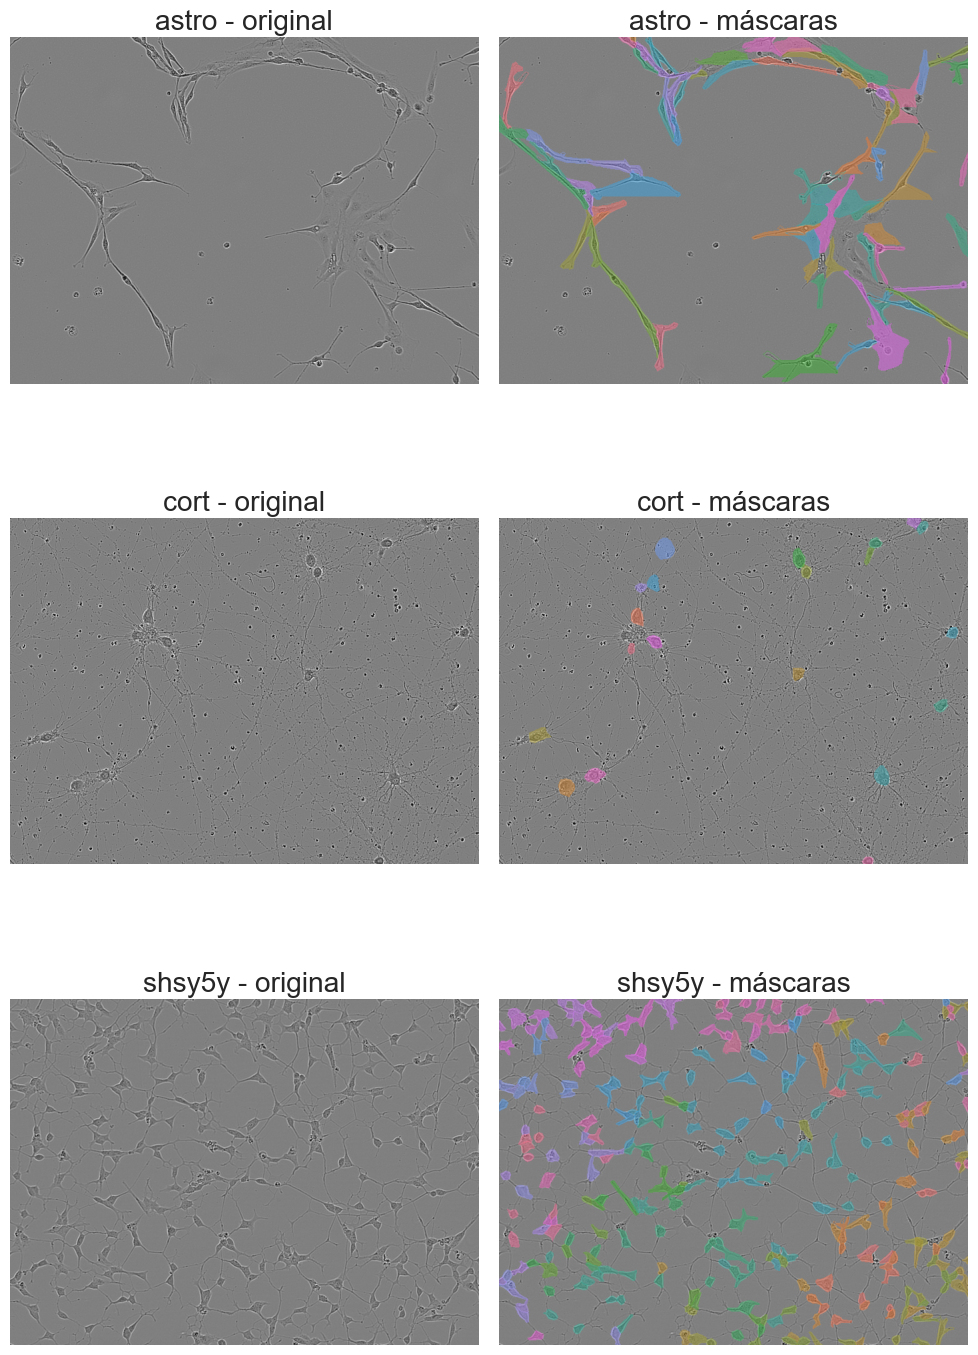

In [30]:
# 3. Imágenes de ejemplo por tipo de célula
fig, axes = plt.subplots(3, 2, figsize=(10, 15))
for i, ctype in enumerate(['astro', 'cort', 'shsy5y']):
    sample = df_img[df_img['cell_type'] == ctype].sample(1).iloc[0]
    img = cv2.cvtColor(cv2.imread(sample['ruta_imagen']), cv2.COLOR_BGR2RGB)
    rles = df_train[df_train['id'] == sample['id_imagen']]['annotation'].dropna().tolist()
    masks = [rle_decode(rle, (sample['height'], sample['width'])) for rle in rles]
    overlay = overlay_masks(img, masks)
    axes[i, 0].imshow(img); axes[i, 0].set_title(f'{ctype} - original'); axes[i, 0].axis('off')
    axes[i, 1].imshow(overlay); axes[i, 1].set_title(f'{ctype} - máscaras'); axes[i, 1].axis('off')

plt.tight_layout(); plt.show()

**Análisis visual comparativo: imágenes originales y máscaras por tipo celular**

Se presenta una comparación entre imágenes originales y sus respectivas máscaras de segmentación para los tipos celulares `astro`, `cort` y `shsy5y`, con el objetivo de identificar diferencias morfológicas, espaciales y estructurales relevantes para el proceso de segmentación.

**Tipo celular: astro**

Las imágenes correspondientes a `astro` muestran células con:

* Morfologías alargadas e irregulares.
* Estructuras ramificadas y extensiones finas.
* Baja densidad celular relativa, pero con gran ocupación espacial por célula.

Las máscaras reflejan objetos complejos y de geometría variable, con formas no compactas y límites difusos en algunas regiones.

**Implicaciones**

* La segmentación de `astro` representa un desafío debido a:

  * contornos delgados,
  * estructuras ramificadas,
  * y posibles conexiones entre células.
* Los modelos deberán capturar detalles finos y relaciones espaciales complejas.

**Tipo celular: cort**

Las imágenes de `cort` presentan:

* Baja densidad celular.
* Células pequeñas y dispersas.
* Gran cantidad de fondo visible.

Las máscaras muestran objetos relativamente compactos y bien separados entre sí.

**Implicaciones**

* La segmentación resulta potencialmente más sencilla por la baja superposición celular.
* Sin embargo, el pequeño tamaño de los objetos puede dificultar la detección precisa.
* Existe riesgo de falsos negativos en células pequeñas o de bajo contraste.

**Tipo celular: shsy5y**

Las imágenes de `shsy5y` exhiben:

* Alta densidad celular.
* Fuerte agrupamiento espacial.
* Mayor uniformidad en tamaño y forma respecto a otras clases.

Las máscaras evidencian una gran cantidad de objetos cercanos entre sí, con regiones potencialmente superpuestas.

**Implicaciones**

* La alta densidad incrementa la complejidad de segmentación.
* El modelo debe diferenciar correctamente células adyacentes y evitar fusiones entre máscaras.
* Puede existir mayor sensibilidad a errores de separación de instancias.

**Comparación global entre tipos celulares**

La comparación visual permite identificar diferencias estructurales importantes:

| Tipo celular | Densidad | Tamaño  | Complejidad morfológica |
| ------------ | -------- | ------- | ----------------------- |
| astro        | Media    | Grande  | Alta                    |
| cort         | Baja     | Pequeño | Baja                    |
| shsy5y       | Alta     | Media   | Media                   |

Estas diferencias indican que el dataset posee una elevada heterogeneidad visual y morfológica, lo cual representa un reto significativo para los modelos de segmentación.

**Implicaciones para el modelado**

Las variaciones observadas sugieren que:

* El modelo deberá generalizar sobre múltiples escalas y morfologías celulares.
* Diferentes clases pueden requerir distintos niveles de sensibilidad espacial.
* Las arquitecturas multi-escala y los mecanismos de atención podrían resultar beneficiosos.

Asimismo, las diferencias entre clases justifican:

* evaluación estratificada por tipo celular,
* augmentations específicas,
* y análisis detallado de errores según morfología.
